<a href="https://colab.research.google.com/github/OjashShakya/Ojash_Shakya_2408654_AI_Worksheets/blob/main/2408654_OjashShakya_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 3: Language Tasks



## (Sentiment Analysis) Text Classification with RNN - Book Review using RNN, LSTM, and Word2Vec Embeddings

## Text Preprocessing, Tokenization and Sequence Padding:

### Mount and Load, Clean and Visualize Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the CSV into a DataFrame
import pandas as pd
file_path = '/content/drive/MyDrive/6th Sem/Artificial Intelligence and Machine Learning/Coursework/Book Review Dataset/Book_review.csv'
df = pd.read_csv(file_path)

# show first rows
df.head()

,Unnamed: 0,rating,reviewText,summary
0,0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,4,5,"This isn't the kind of book I normally read, a...",Great Story!


In [ ]:
# Keep useful columns only
df = df[['rating', 'reviewText']]

# Rename column
df.rename(columns={'reviewText': 'review'}, inplace=True)

# Show dataset info
print(df.head())
print(df.shape)

   rating                                             review
0       5  This book was the very first bookmobile book I...
1       1  When I read the description for this book, I c...
2       5  I just had to edit this review. This book is a...
3       5  I don't normally buy 'mystery' novels because ...
4       5  This isn't the kind of book I normally read, a...
(12000, 2)


The dataset has:

summary
unnamed index

But for sentiment analysis:
 only review text matters
 rating becomes label

Keeping unnecessary columns:
 increases confusion
 makes preprocessing messy

### Creating the Sentiment labels

In [ ]:
# Convert ratings into sentiment labels

def sentiment_label(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["rating"].apply(sentiment_label)

# Check class distribution
print(df["sentiment"].value_counts())

sentiment
positive    6000
negative    4000
neutral     2000
Name: count, dtype: int64


Deep learning models need:
classification labels

We convert ratings into:

negative
neutral
positive

This becomes:

Multiclass Sentiment Classification

### Visualize Sentiment Distribution

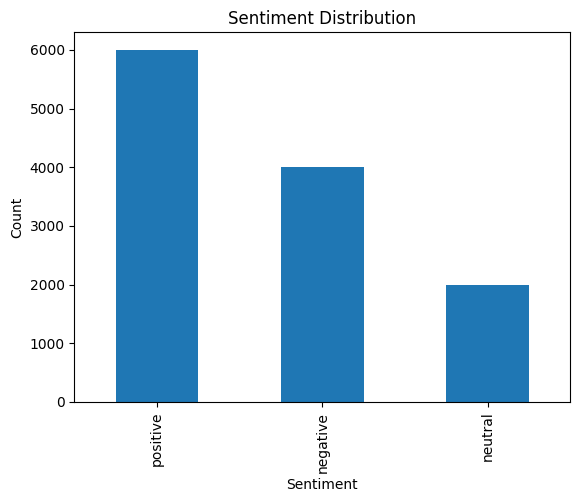

In [ ]:
import matplotlib.pyplot as plt

# Plot sentiment distribution
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

### Import NLP Libraries

In [ ]:
import re
import nltk
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

Library	Purpose
re =	text cleaning,
stopwords =	remove common useless words,
lemmatizer =	convert words to base form

### Create Stopwords & Lemmatizer

In [ ]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

### Create Cleaning Function

In [ ]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize words
    words = text.split()

    # Remove stopwords and lemmatize
    cleaned_words = []

    for word in words:

        if word not in stop_words:
            lemma_word = lemmatizer.lemmatize(word)
            cleaned_words.append(lemma_word)

    return " ".join(cleaned_words)

# Apply Cleaning
df['clean_review'] = df['review'].apply(clean_text)

print(df[['review', 'clean_review']].head())


                                              review  \
0  This book was the very first bookmobile book I...   
1  When I read the description for this book, I c...   
2  I just had to edit this review. This book is a...   
3  I don't normally buy 'mystery' novels because ...   
4  This isn't the kind of book I normally read, a...   

                                        clean_review  
0  book first bookmobile book bought school book ...  
1  read description book couldnt wait read downlo...  
2  edit review book believe got right updated rew...  
3  dont normally buy mystery novel dont like howe...  
4  isnt kind book normally read although try limi...  


### Compare Before vs After

In [ ]:
for i in range(3):

    print("\nOriginal Review:\n")
    print(df['review'][i])

    print("\nCleaned Review:\n")
    print(df['clean_review'][i])

    print("\n" + "="*100)


Original Review:

This book was the very first bookmobile book I bought when I was in the school book club. I loved the story then and I bet a dollar to a donut I will love it again. If my memory serves, I bought this book in 5th grade. That would have been about 1961. I am looking forward to reliving the memories.

Cleaned Review:

book first bookmobile book bought school book club loved story bet dollar donut love memory serf bought book th grade would looking forward reliving memory


Original Review:

When I read the description for this book, I couldn't wait to read it. Once I downloaded it to my Kindle, I found it extremely hard to keep reading it.  To be honest, I stopped reading halfway through the book. It began slow and remained a slow, uninteresting read.  It lacked passion; not making love passion, but passion for life. Neither Jada or Aaron were interesting characters and the story was too, too `everything is perfect'.  Everybody is just so understanding and accommodating

### Visualize cleaned text

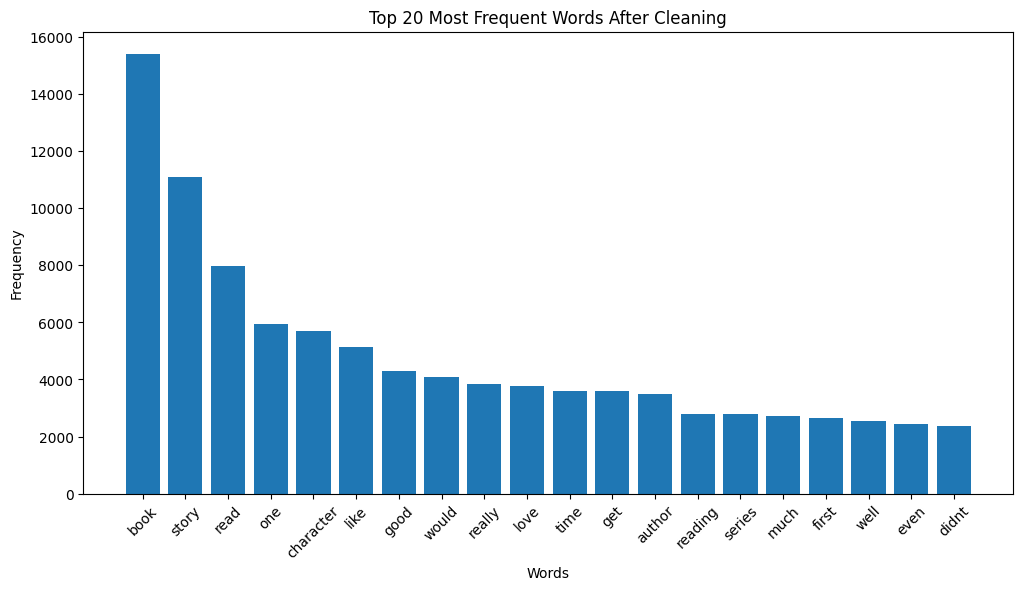

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# combine all cleaned reviews into one text
all_words = " ".join(df["clean_review"]).split()

# count most common words
word_counts = Counter(all_words)

# top 20 words
common_words = word_counts.most_common(20)

words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

This graph shows which words appear most after preprocessing. It is useful for your report because it proves you explored the cleaned dataset.

## Model Building and Training:

### Prepare labels for model training

In [ ]:
from tensorflow.keras.utils import to_categorical

# Convert sentiment labels into numeric labels
label_mapping = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["label"] = df["sentiment"].map(label_mapping)

# Convert labels to categorical format for softmax output
y = to_categorical(df["label"], num_classes=3)

print(df[["sentiment", "label"]].head())
print("Label shape:", y.shape)

  sentiment  label
0  positive      2
1  negative      0
2  positive      2
3  positive      2
4  positive      2
Label shape: (12000, 3)


The model output will have 3 neurons:

negative
neutral
positive

So labels must also be converted into a 3-class format.

### Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

X = df["clean_review"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 9600
Testing samples: 2400


We train on 80% of data and test on 20%.
stratify keeps the class distribution similar in both train and test sets.

### Tokenization

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

VOCAB_SIZE = 5000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index

print("Vocabulary size:", len(word_index))
print("Example text:", X_train.iloc[0])
print("Tokenized example:", X_train_seq[0][:20])

Vocabulary size: 36167
Example text: ok im always starting series book wrong order read first nd book series seems reading taming eliza jane next surethe moment rebecca step stage adam greet immediately feel web attraction thats good shannon writing isthe biting word shared part elaborate dance reader feel wont last long rebecca determined let hair speak cut loose wild west town held check sheriff adamthat somewhat reputation shoot first ask question laterhis deputy newly married eliza jane constantly running adam figure time maybe take nice sweet wife like rebeccca boy surprise start dressing clothes aunt left along house ill reputeyes madam virginal one dare ask adam firstof course adam doesnt like revealing clothes face paintespecially look get men asks everyone call miss becky come unglued well seems miss becky good reason incognitothe suspense bible brigade elizas liberated woman adam bumbling courtship oh will bubble bath wifethis story actually lot storyif know mean never bored 

Neural networks cannot read words directly.
Tokenizer converts words into numbers. for Example: book amazing story  become [12, 45, 89]

### Percentile-based padding

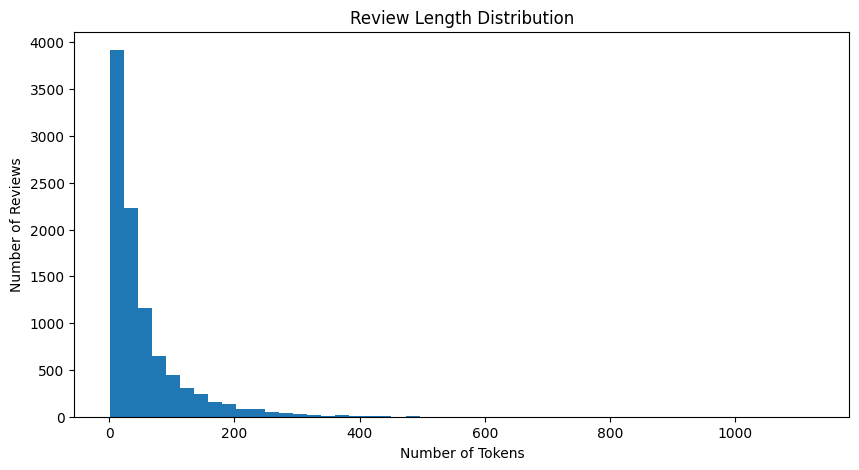

95th percentile sequence length: 183


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# check review lengths
review_lengths = [len(seq) for seq in X_train_seq]

plt.figure(figsize=(10, 5))
plt.hist(review_lengths, bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Reviews")
plt.show()

# use 95th percentile to avoid very long outlier reviews
MAX_LEN = int(np.percentile(review_lengths, 95))

print("95th percentile sequence length:", MAX_LEN)

### Visualization2(Word Cloud)

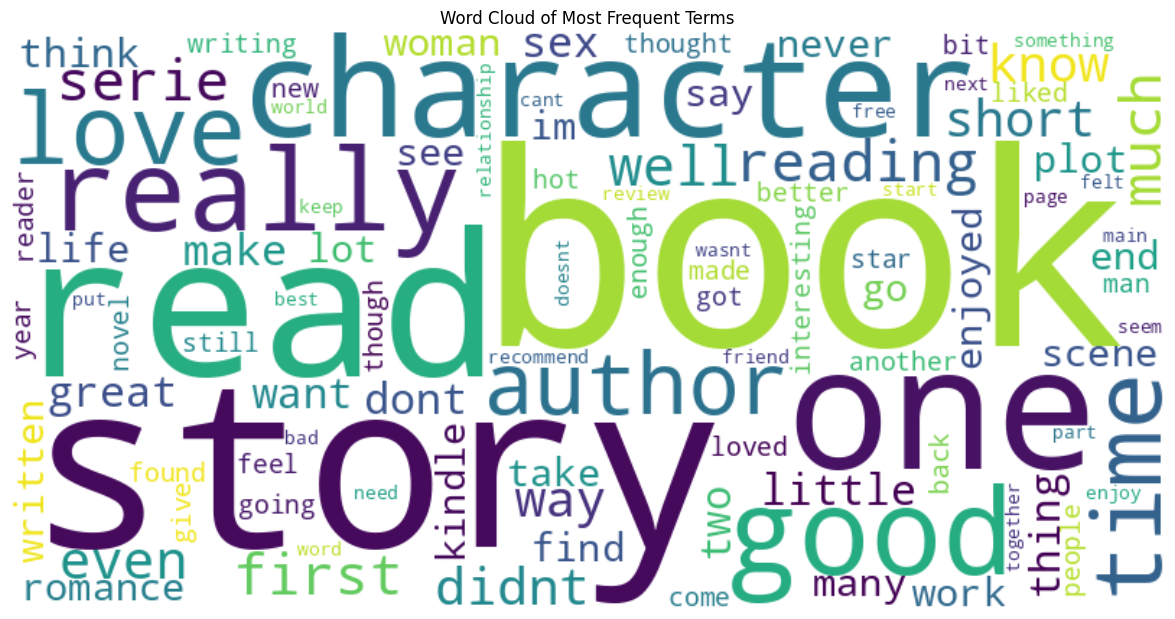

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Join all cleaned reviews into one string
text = ' '.join(df['clean_review'])

# Default stopwords
custom_stopwords = set(STOPWORDS)

# Generate word cloud
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=100,
    collocations=False
).generate(text)

# Display word cloud
plt.figure(figsize=(15, 7.5))

plt.imshow(wc, interpolation='bilinear')

plt.axis('off')

plt.title('Word Cloud of Most Frequent Terms')

plt.show()

The histogram is GOOD.

It shows:

most reviews are short/moderate length
few reviews are extremely long

This justifies using percentile padding.

In [ ]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Padded train shape:", X_train_pad.shape)
print("Padded test shape:", X_test_pad.shape)

Padded train shape: (9600, 183)
Padded test shape: (2400, 183)


RNN and LSTM need equal-length input.
Padding makes every review the same length.

Using the 95th percentile is better than choosing a random length because very long reviews can increase training time unnecessarily.

## Model Training and Evaluation

### Buildling simple RNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout

# Embedding size
EMBEDDING_DIM = 128

# Build RNN model
rnn_model = Sequential([

    # Input layer
    Input(shape=(MAX_LEN,)),

    # Embedding layer
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    # RNN layer
    SimpleRNN(64),

    # Dropout for regularization
    Dropout(0.5),

    # Dense hidden layer
    Dense(32, activation='relu'),

    # Output layer
    Dense(3, activation='softmax')
])

# Compile model
rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show summary
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 183, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,531 (2.50 MB)

 Trainable params: 654,531 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

### Train Model

In [ ]:
import time
from tensorflow.keras.callbacks import Callback, EarlyStopping

# 1. Define the Custom Callback Class first
class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.train_start = time.time()
        self.total_time = 0 # Initialize to avoid AttributeError if training fails early

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        print(f" - epoch_time: {elapsed:.1f}s")
        self.epoch_times.append(elapsed)

    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start

# 2. Instantiate the callbacks
time_cb = TimeHistory()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 3. Train the model
history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, time_cb] # time_cb is now defined!
)

# 4. Report total training time
print(f"\nTotal training time: {time_cb.total_time:.1f}s")

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4120 - loss: 1.0669 - epoch_time: 21.7s
240/240 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - accuracy: 0.4702 - loss: 1.0342 - val_accuracy: 0.5016 - val_loss: 1.0129
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5115 - loss: 1.0084 - epoch_time: 17.4s
240/240 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - accuracy: 0.4983 - loss: 1.0236 - val_accuracy: 0.4021 - val_loss: 1.0395
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4573 - loss: 1.0617 - epoch_time: 18.5s
240/240 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.4641 - loss: 1.0567 - val_accuracy: 0.4490 - val_loss: 1.0259
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4869 - loss: 1.0307 - epoch_time: 17.9s
240/240 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.4816 - loss: 1.0304 - val_accuracy: 0.5016 - val_loss: 1.0086
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4760 - loss: 1.0344 - epoch_t

### Evaluate Model

In [ ]:
rnn_loss, rnn_acc = rnn_model.evaluate(
    X_test_pad,
    y_test
)

print("RNN Test Accuracy:", rnn_acc)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4896 - loss: 1.0138
RNN Test Accuracy: 0.4895833432674408


### Plot Training Graphs

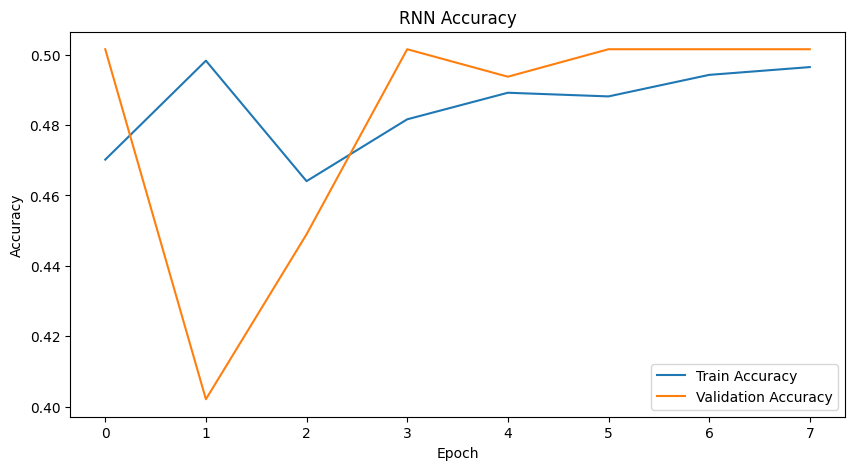

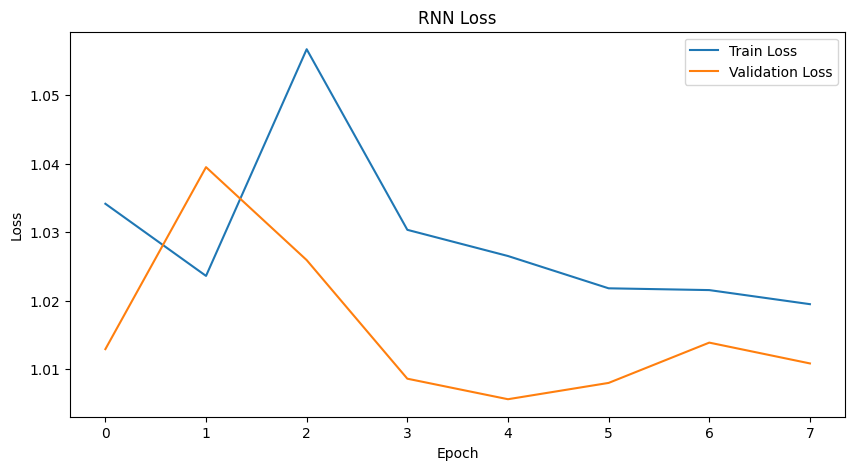

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()


# Loss graph
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

### Building Bidirectional LSTM with a trainable Embedding layer

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

# Build LSTM model
lstm_model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    ),

    Bidirectional(LSTM(64)),

    Dropout(0.5),

    # LSTM(64),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(3, activation='softmax')
])

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show summary
lstm_model.summary(
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 183, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 747,267 (2.85 MB)

 Trainable params: 747,267 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training Bidirectional LSTM

In [ ]:
import time
from tensorflow.keras.callbacks import Callback, EarlyStopping

# 1. Define the timing callback class
class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.train_start = time.time()

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):

        elapsed = time.time() - self.epoch_start
        print(f" - epoch_time: {elapsed:.1f}s")
        self.epoch_times.append(elapsed)

    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start

# 2. Instantiate both callbacks
time_cb = TimeHistory()
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 3. Train the LSTM model
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, time_cb] # Pass both here
)

# 4. Report the results
print(f"\nTotal LSTM training time: {time_cb.total_time:.1f}s")

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.5297 - loss: 0.9732 - epoch_time: 66.3s
240/240 ━━━━━━━━━━━━━━━━━━━━ 66s 255ms/step - accuracy: 0.6124 - loss: 0.8745 - val_accuracy: 0.7141 - val_loss: 0.7211
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.7488 - loss: 0.6336 - epoch_time: 85.1s
240/240 ━━━━━━━━━━━━━━━━━━━━ 85s 269ms/step - accuracy: 0.7497 - loss: 0.6296 - val_accuracy: 0.7047 - val_loss: 0.7133
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.8184 - loss: 0.4807 - epoch_time: 135.8s
240/240 ━━━━━━━━━━━━━━━━━━━━ 136s 493ms/step - accuracy: 0.8100 - loss: 0.4991 - val_accuracy: 0.7042 - val_loss: 0.8527
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8538 - loss: 0.4030 - epoch_time: 117.2s
240/240 ━━━━━━━━━━━━━━━━━━━━ 117s 389ms/step - accuracy: 0.8518 - loss: 0.4025 - val_accuracy: 0.6615 - val_loss: 0.8763
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.8941 - loss: 0.3

### Evaluate LSTM

In [ ]:
lstm_loss, lstm_acc = lstm_model.evaluate(
    X_test_pad,
    y_test
)

print("LSTM Test Accuracy:", lstm_acc)

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.7142 - loss: 0.6928
LSTM Test Accuracy: 0.7141666412353516


### Plot LSTM Graphs

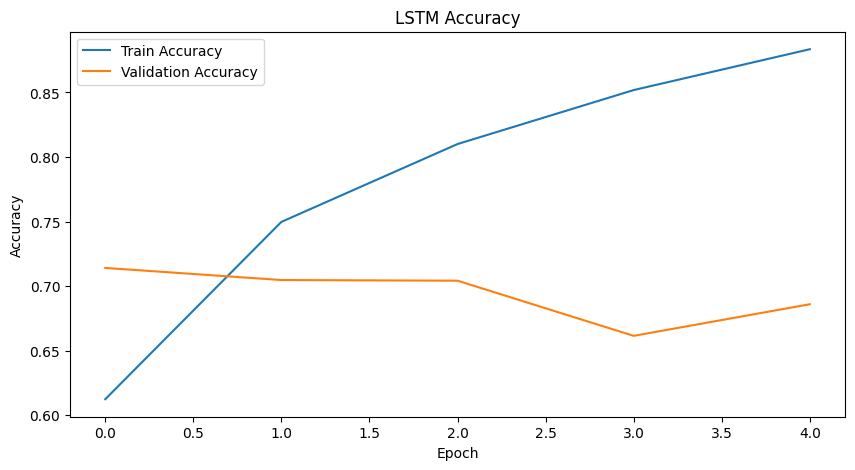

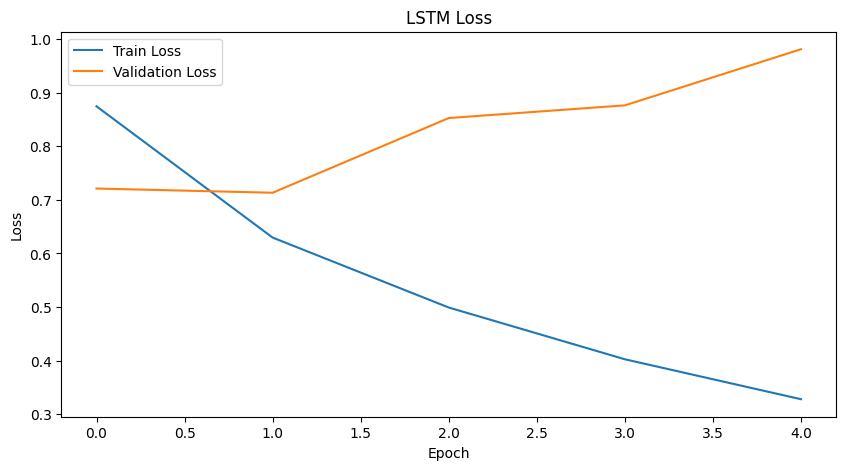

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()


# Loss graph
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

Compared to RNN:
 higher validation accuracy
 better learning trend
 more stable performance

## Installing gensim

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.8 MB/s eta 0:00:00


### Load pretrained embedding

We will use GloVe 50D, because it is smaller and faster in Colab.

In [ ]:
import gensim.downloader as api

embedding_model = api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


Instead of learning word meanings from zero, this model already has word knowledge from a large text corpus.

Example:

1. good, great, excellent have similar meanings

2. bad, boring, poor are also related

### Create embedding matrix

In [ ]:
import numpy as np

EMBEDDING_DIM = 50

word_index = tokenizer.word_index

embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

for word, i in word_index.items():
    if i < VOCAB_SIZE:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (5000, 50)


It creates a matrix where:

1. each row = one word
2. each column = word meaning values

## Build Word2Vec/GloVe LSTM model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

word2vec_lstm = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

word2vec_lstm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

word2vec_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 183, 50)        │       250,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,619 (1.07 MB)

 Trainable params: 31,619 (123.51 KB)

 Non-trainable params: 250,000 (976.56 KB)

Why trainable=False?

Because we are using pretrained word vectors.
We keep them fixed so the model uses already learned word meanings.

## Train Word2Vec/GloVe LSTM

In [ ]:
import time
from tensorflow.keras.callbacks import Callback, EarlyStopping

# 1. Define the timing callback class
class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.train_start = time.time()

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        print(f" - epoch_time: {elapsed:.1f}s")
        self.epoch_times.append(elapsed)

    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start

# 2. Instantiate both callbacks
time_cb = TimeHistory()
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 3. Train the LSTM model
history_word2vec = word2vec_lstm.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, time_cb] # Pass both here
)

# 4. Report the results
print(f"\nTotal LSTM training time: {time_cb.total_time:.1f}s")

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.4897 - loss: 1.0387 - epoch_time: 44.3s
240/240 ━━━━━━━━━━━━━━━━━━━━ 44s 167ms/step - accuracy: 0.4983 - loss: 1.0238 - val_accuracy: 0.5016 - val_loss: 1.0071
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5029 - loss: 1.0122 - epoch_time: 20.8s
240/240 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - accuracy: 0.5004 - loss: 1.0142 - val_accuracy: 0.5016 - val_loss: 1.0034
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4981 - loss: 1.0146 - epoch_time: 22.2s
240/240 ━━━━━━━━━━━━━━━━━━━━ 22s 92ms/step - accuracy: 0.5001 - loss: 1.0119 - val_accuracy: 0.5021 - val_loss: 1.0038
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5036 - loss: 1.0111 - epoch_time: 42.3s
240/240 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.5014 - loss: 1.0098 - val_accuracy: 0.5016 - val_loss: 1.0050
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5071 - loss: 1.0002 - epoch

### Evaluate model

In [ ]:
word2vec_loss, word2vec_acc = word2vec_lstm.evaluate(
    X_test_pad,
    y_test
)

print("Word2Vec/GloVe LSTM Test Accuracy:", word2vec_acc)

75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5013 - loss: 1.0103
Word2Vec/GloVe LSTM Test Accuracy: 0.5012500286102295


### Plot graphs

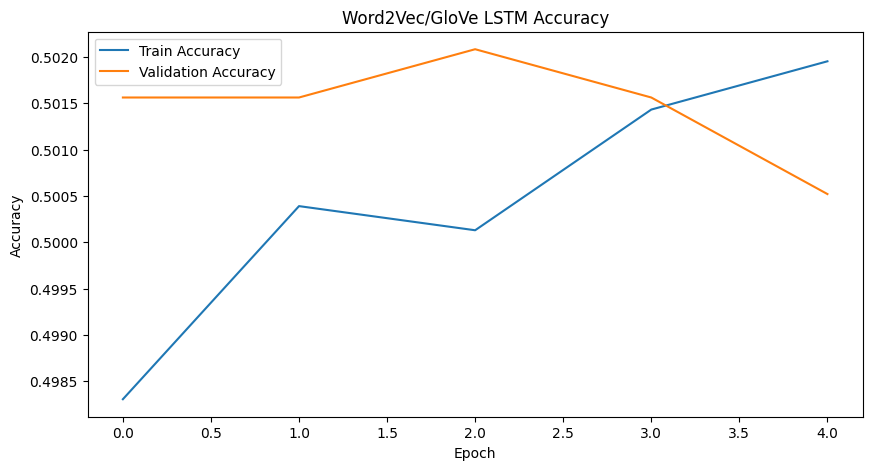

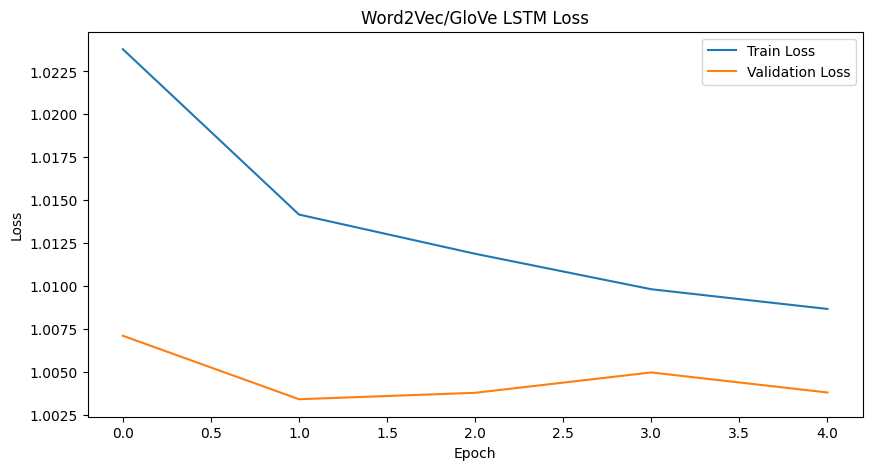

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history_word2vec.history['accuracy'], label='Train Accuracy')
plt.plot(history_word2vec.history['val_accuracy'], label='Validation Accuracy')
plt.title("Word2Vec/GloVe LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history_word2vec.history['loss'], label='Train Loss')
plt.plot(history_word2vec.history['val_loss'], label='Validation Loss')
plt.title("Word2Vec/GloVe LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Predictions

In [ ]:
import numpy as np

# RNN predictions
rnn_pred = np.argmax(rnn_model.predict(X_test_pad), axis=1)

# LSTM predictions
lstm_pred = np.argmax(lstm_model.predict(X_test_pad), axis=1)

# Word2Vec predictions
word2vec_pred = np.argmax(word2vec_lstm.predict(X_test_pad), axis=1)

# True labels
y_true = np.argmax(y_test, axis=1
                   )

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step


## Classification Report

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Generate reports as dictionaries
rnn_report = classification_report(
    y_true,
    rnn_pred,
    target_names=["Negative", "Neutral", "Positive"],
    output_dict=True
)

lstm_report = classification_report(
    y_true,
    lstm_pred,
    target_names=["Negative", "Neutral", "Positive"],
    output_dict=True
)

word2vec_report = classification_report(
    y_true,
    word2vec_pred,
    target_names=["Negative", "Neutral", "Positive"],
    output_dict=True
)

# Convert to DataFrames
rnn_df = pd.DataFrame(rnn_report).transpose()

lstm_df = pd.DataFrame(lstm_report).transpose()

word2vec_df = pd.DataFrame(word2vec_report).transpose()

# Round values
rnn_df = rnn_df.round(4)
lstm_df = lstm_df.round(4)
word2vec_df = word2vec_df.round(4)

# Display tables
print("===== RNN Classification Report =====")
display(rnn_df)

print("\n===== LSTM Classification Report =====")
display(lstm_df)

print("\n===== Word2Vec/GloVe Classification Report =====")
display(word2vec_df)

===== RNN Classification Report =====


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

,precision,recall,f1-score,support
Negative,0.3403,0.0812,0.1312,800.0000
Neutral,0.0000,0.0000,0.0000,400.0000
Positive,0.5025,0.9250,0.6512,1200.0000
accuracy,0.4896,0.4896,0.4896,0.4896
macro avg,0.2809,0.3354,0.2608,2400.0000
weighted avg,0.3647,0.4896,0.3693,2400.0000



===== LSTM Classification Report =====


,precision,recall,f1-score,support
Negative,0.6908,0.8100,0.7457,800.0000
Neutral,0.3766,0.2175,0.2758,400.0000
Positive,0.7953,0.8158,0.8054,1200.0000
accuracy,0.7142,0.7142,0.7142,0.7142
macro avg,0.6209,0.6144,0.6090,2400.0000
weighted avg,0.6907,0.7142,0.6972,2400.0000



===== Word2Vec/GloVe Classification Report =====


,precision,recall,f1-score,support
Negative,1.0000,0.0038,0.0075,800.0000
Neutral,0.0000,0.0000,0.0000,400.0000
Positive,0.5006,1.0000,0.6672,1200.0000
accuracy,0.5012,0.5012,0.5012,0.5012
macro avg,0.5002,0.3346,0.2249,2400.0000
weighted avg,0.5836,0.5012,0.3361,2400.0000


### Confusion Matrix (LSTM)

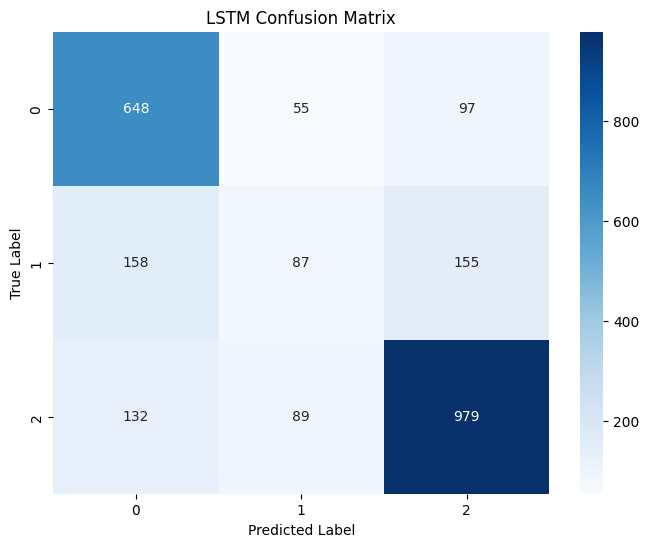

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, lstm_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("LSTM Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Final Comparsion Table

In [ ]:
import pandas as pd

results_df = pd.DataFrame({

    "Model": [
        "Simple RNN",
        "LSTM",
        "Word2Vec/GloVe + LSTM"
    ],

    "Test Accuracy": [
        rnn_acc,
        lstm_acc,
        word2vec_acc
    ]
})

results_df = results_df.round(4)

results_df

,Model,Test Accuracy
0,Simple RNN,0.4896
1,LSTM,0.7142
2,Word2Vec/GloVe + LSTM,0.5013


### Comparision Graph

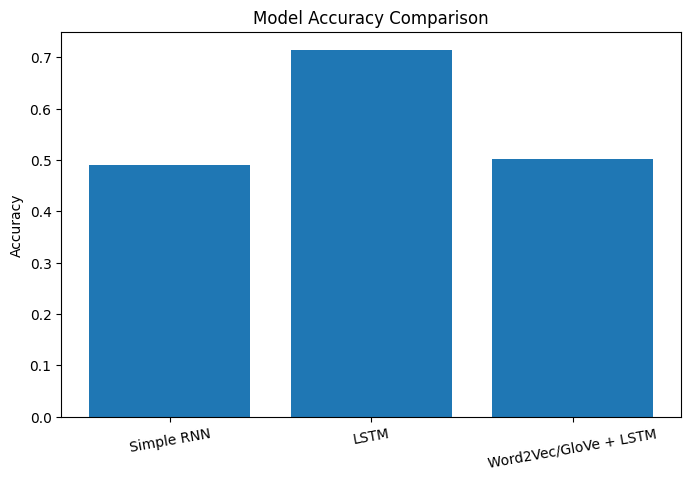

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Test Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=10)

plt.show()

## Model Train Accuracy description

### Simple RNN - Weak Performance (About 49%)

**RNN struggled because:**

1. Simple RNN cannot remember long dependencies well.

2. reviews are long (MAX_LEN = 183)

3. vanishing gradient issue

**From graph:**

1. training and validation accuracy stayed flat

2. model could not learn complex sentiment patterns

### LSTM — BEST MODEL (About 71.42%)

This is the strongest model.

**Why it performed better:**
1. remembers long-term dependencies

2. handles sequential text better

3. captures sentiment context more effectively

**From graph:**

1. training accuracy improved strongly

2. validation accuracy reached ~72%

### Word2Vec/GloVe + LSTM — Weak (About 50%)

**Why it may have underperformed:**

1. pretrained embeddings were generic

2. book-review vocabulary may differ from pretrained corpus

3. embeddings were frozen (trainable=False)

4. dataset-specific language may not align well